# Ablation study on the simulation dataset

In [ ]:
# import sys
# sys.path.append(r'/import/home2/yzengbj/my_project/code')
# sys.path.append(r'/import/home2/share/yqzeng/MacSGP/codes')

# import pandas as pd
# import numpy as np
# import scanpy as sc
# import anndata as ad
# import os
# import warnings
# import libpysal
# import esda
# from libpysal.weights import KNN

# warnings.filterwarnings("ignore")
# os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# import simulation as construct_st
# import MacSGP

# # ============================================================
# # Experiment parameters (same as ablation_graph_rep5.py)
# # ============================================================
# BASE_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/ablation'

# factor_pattern = 'gradient_y'
# factor_celltype = [0]

# n_spots = 2000
# n_genes = 2000
# n_celltypes = 2
# n_cells = 500
# n_covariates = 1
# n_loading_genes = 400
# n_groups = 4
# library_size = 1000
# prop_confound = True
# prop_min = 0.1
# prop_max = 0.9
# v = 4

# same_tau = True
# spots_effects = False
# platform_effects = False

# ref_noise_ratios = np.arange(3.0, 6.5, 0.5)  # 3.0, 3.5, ..., 6.0
# SEEDS = [2025001, 2025002, 2025003, 2025004, 2025005]  # same as ablation_graph_rep5.py

# # RAE conditions: reuse existing adata_result_l{n}.h5ad from ablation_graph_rep5.py
# # noRAE conditions: run fresh (Stage1 + Stage2 with coef_fe=0)
# RAE_CONFIGS = [
#     {'n_layers': 0, 'label': 'L0_RAE',   'existing_file': 'adata_result_l0.h5ad'},
#     {'n_layers': 4, 'label': 'L4_RAE',   'existing_file': 'adata_result_l4.h5ad'},
# ]
# NORAE_CONFIGS = [
#     {'n_layers': 0, 'label': 'L0_noRAE', 'save_file': 'adata_result_L0_noRAE.h5ad'},
#     {'n_layers': 4, 'label': 'L4_noRAE', 'save_file': 'adata_result_L4_noRAE.h5ad'},
# ]

# # ============================================================
# # Evaluation
# # ============================================================
# def evaluate_result(adata_result, k_moran=20):
#     sub = adata_result[adata_result.obsm['proportion']['celltype_0'] > 0.0].copy()

#     factor_true = sub.obsm['simulated_factor']
#     factor_pred = sub.obsm['factor']['celltype_0']
#     coords = sub.obsm['spatial']
#     w = KNN.from_array(coords, k=k_moran)
#     w.transform = 'r'
#     bi = esda.Moran_BV(factor_true, factor_pred, w, permutations=999)

#     loading_true = sub.varm['simulated_loading'][:, 0]
#     loading_pred = sub.varm['loading']['celltype_0']
#     cor = np.corrcoef(loading_true, loading_pred)[0, 1]

#     return bi.I, bi.p_sim, cor

# # ============================================================
# # Main loop
# # ============================================================
# results = []

# for ratio in ref_noise_ratios:
#     ratio_str = f"{ratio:.1f}"
#     print(f"\n{'='*60}")
#     print(f"ref_noise_ratio = {ratio_str}")
#     print(f"{'='*60}")

#     for seed_idx, seed in enumerate(SEEDS):
#         print(f"\n  *** Seed {seed_idx+1}/{len(SEEDS)}: {seed} ***")

#         exp_path = os.path.join(
#             BASE_PATH,
#             f'noise_{ratio_str}_lib{library_size}_v{v}',
#             f'seed_{seed}'
#         )
#         os.makedirs(exp_path, exist_ok=True)

#         st_path  = os.path.join(exp_path, 'adata_st.h5ad')
#         ref_path = os.path.join(exp_path, 'adata_ref.h5ad')

#         # ---- RAE conditions: load existing results from ablation_graph_rep5.py ----
#         for cfg in RAE_CONFIGS:
#             label       = cfg['label']
#             result_path = os.path.join(exp_path, cfg['existing_file'])
#             print(f"\n    --- {label} (loading from {cfg['existing_file']}) ---")

#             if not os.path.exists(result_path):
#                 print(f"      WARNING: {result_path} not found, skipping.")
#                 continue

#             adata_result = sc.read_h5ad(result_path)
#             moran_I, moran_p, loading_cor = evaluate_result(adata_result)
#             print(f"      Moran's I: {moran_I:.4f}  (p={moran_p:.4f})")
#             print(f"      Loading corr: {loading_cor:.4f}")

#             results.append({
#                 'ref_noise_ratio': ratio, 'seed': seed,
#                 'n_layers': cfg['n_layers'], 'use_rae': True, 'label': label,
#                 'moran_I': moran_I, 'moran_p': moran_p, 'loading_corr': loading_cor,
#             })

#         # ---- noRAE conditions: run Stage1+Stage2 only if any result is missing ----
#         norae_paths   = [os.path.join(exp_path, cfg['save_file']) for cfg in NORAE_CONFIGS]
#         norae_missing = [not os.path.exists(p) for p in norae_paths]

#         if any(norae_missing):
#             print("\n    Running Stage 1 (DeconvNet) for noRAE variants...")
#             adata_st  = sc.read_h5ad(st_path)
#             adata_ref = sc.read_h5ad(ref_path)
#             MacSGP.utils.Cal_Spatial_Net(adata_st, mode='KNN', k_cutoff=12)
#             adata_st_proc, adata_basis = MacSGP.utils.preprocess(
#                 adata_st, adata_ref, celltype_ref_col="celltype", n_hvg_group=1000
#             )
#             model_deconv = MacSGP.model.Model_deconv(
#                 adata_st_proc, adata_basis, n_layers=4, training_steps=10000
#             )
#             model_deconv.train(step_interval=1000)
#             adata_st_deconv = model_deconv.eval()
#         else:
#             adata_st_deconv = None
#             adata_basis     = None

#         for cfg, result_path, is_missing in zip(NORAE_CONFIGS, norae_paths, norae_missing):
#             label    = cfg['label']
#             n_layers = cfg['n_layers']
#             print(f"\n    --- {label} (n_layers={n_layers}, coef_fe=0) ---")

#             if is_missing:
#                 model = MacSGP.model.Model(
#                     adata_st_deconv, adata_basis,
#                     n_layers=n_layers, training_steps=3000, coef_fe=0
#                 )
#                 model.train(step_interval=600)
#                 adata_result = model.eval()
#                 adata_result.write_h5ad(result_path)
#             else:
#                 print(f"      Loading existing result...")
#                 adata_result = sc.read_h5ad(result_path)

#             moran_I, moran_p, loading_cor = evaluate_result(adata_result)
#             print(f"      Moran's I: {moran_I:.4f}  (p={moran_p:.4f})")
#             print(f"      Loading corr: {loading_cor:.4f}")

#             results.append({
#                 'ref_noise_ratio': ratio, 'seed': seed,
#                 'n_layers': n_layers, 'use_rae': False, 'label': label,
#                 'moran_I': moran_I, 'moran_p': moran_p, 'loading_corr': loading_cor,
#             })

# # ============================================================
# # Save raw results
# # ============================================================
# df_results = pd.DataFrame(results)
# out_csv = os.path.join(BASE_PATH, f'ablation_graph_rae_all_seeds_lib{library_size}_v{v}.csv')
# df_results.to_csv(out_csv, index=False)
# print(f"\nSaved raw results to {out_csv}")

# # ============================================================
# # Summary: mean ± std over seeds, absolute values
# # ============================================================
# df_results['moran_I_abs'] = df_results['moran_I'].abs()
# df_results['loading_corr_abs'] = df_results['loading_corr'].abs()

# df_summary = (
#     df_results
#     .groupby(['ref_noise_ratio', 'label'])
#     .agg(
#         moran_I_abs_mean=('moran_I_abs', 'mean'),
#         moran_I_abs_std=('moran_I_abs', 'std'),
#         moran_p_mean=('moran_p', 'mean'),
#         loading_corr_abs_mean=('loading_corr_abs', 'mean'),
#         loading_corr_abs_std=('loading_corr_abs', 'std'),
#     )
#     .reset_index()
# )
# summary_csv = os.path.join(BASE_PATH, f'ablation_graph_rae_summary_lib{library_size}_v{v}.csv')
# df_summary.to_csv(summary_csv, index=False)

# print(f"\n{'='*60}")
# print("Summary (|mean| ± std over 5 seeds):")
# print(f"{'='*60}")
# print(df_summary.to_string(index=False))

# # ============================================================
# # Pivot table: easy comparison across the 4 conditions
# # ============================================================
# labels = [cfg['label'] for cfg in RAE_CONFIGS + NORAE_CONFIGS]

# for metric, col_mean, col_std in [
#     ("|Moran's I|", 'moran_I_abs_mean', 'moran_I_abs_std'),
#     ("|Loading Corr|", 'loading_corr_abs_mean', 'loading_corr_abs_std'),
# ]:
#     print(f"\n{metric} — mean ± std by condition:")
#     print(f"{'='*60}")
#     pivot_mean = df_summary.pivot(index='ref_noise_ratio', columns='label', values=col_mean)
#     pivot_std  = df_summary.pivot(index='ref_noise_ratio', columns='label', values=col_std)
#     disp = pd.DataFrame(index=pivot_mean.index)
#     for lbl in labels:
#         if lbl in pivot_mean.columns:
#             disp[lbl] = [
#                 f"{m:.4f}±{s:.4f}"
#                 for m, s in zip(pivot_mean[lbl], pivot_std[lbl])
#             ]
#     # Add difference columns for the two key comparisons
#     if 'L0_RAE' in pivot_mean.columns and 'L4_RAE' in pivot_mean.columns:
#         disp['Δ GNN (L4−L0, RAE)'] = (pivot_mean['L4_RAE'] - pivot_mean['L0_RAE']).map(lambda x: f"{x:+.4f}")
#     if 'L4_RAE' in pivot_mean.columns and 'L4_noRAE' in pivot_mean.columns:
#         disp['Δ RAE (RAE−noRAE, L4)'] = (pivot_mean['L4_RAE'] - pivot_mean['L4_noRAE']).map(lambda x: f"{x:+.4f}")
#     print(disp.to_string())

In [1]:
import sys
sys.path.append(r'/import/home2/yzengbj/my_project/code')

import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import scipy.io
import matplotlib.pyplot as plt
import os

import simulation as construct_st

In [ ]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family'       : 'Helvetica',
    'font.size'         : 7,
    'axes.titlesize'    : 8,
    'axes.labelsize'    : 7,
    'xtick.labelsize'   : 6.5,
    'ytick.labelsize'   : 6.5,
    'axes.linewidth'    : 0.5,
    'xtick.major.width' : 0.5,
    'ytick.major.width' : 0.5,
    'xtick.major.size'  : 2.5,
    'ytick.major.size'  : 2.5,
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'savefig.dpi'       : 300,
    'figure.dpi'        : 150,
})

In [ ]:
# ============================================================
# Load 2x2 ablation results (GNN × RAE)
# ============================================================
import pandas as pd
import numpy as np
import os

BASE_PATH = '/import/home2/share/yqzeng/MacSGP/experiments/ablation'
library_size = 1000
v = 4

df_rae_all = pd.read_csv(
    os.path.join(BASE_PATH, f'ablation_graph_rae_all_seeds_lib{library_size}_v{v}.csv')
)
df_rae_all['moran_I_abs']      = df_rae_all['moran_I'].abs()
df_rae_all['loading_corr_abs'] = df_rae_all['loading_corr'].abs()

df_rae_summary = pd.read_csv(
    os.path.join(BASE_PATH, f'ablation_graph_rae_summary_lib{library_size}_v{v}.csv')
)

noise_levels = sorted(df_rae_summary['ref_noise_ratio'].unique())
#print(df_rae_summary.to_string(index=False))

ref_noise_ratios_show = [3.5,4.0,4.5,5.0,5.5]
df_rae_summary_show = df_rae_summary[df_rae_summary['ref_noise_ratio'].isin(ref_noise_ratios_show)]
noise_levels = ref_noise_ratios_show

Saved: /import/home2/share/yqzeng/MacSGP/experiments/ablation/ablation_graph_rae_lib1000_v4.pdf / .png


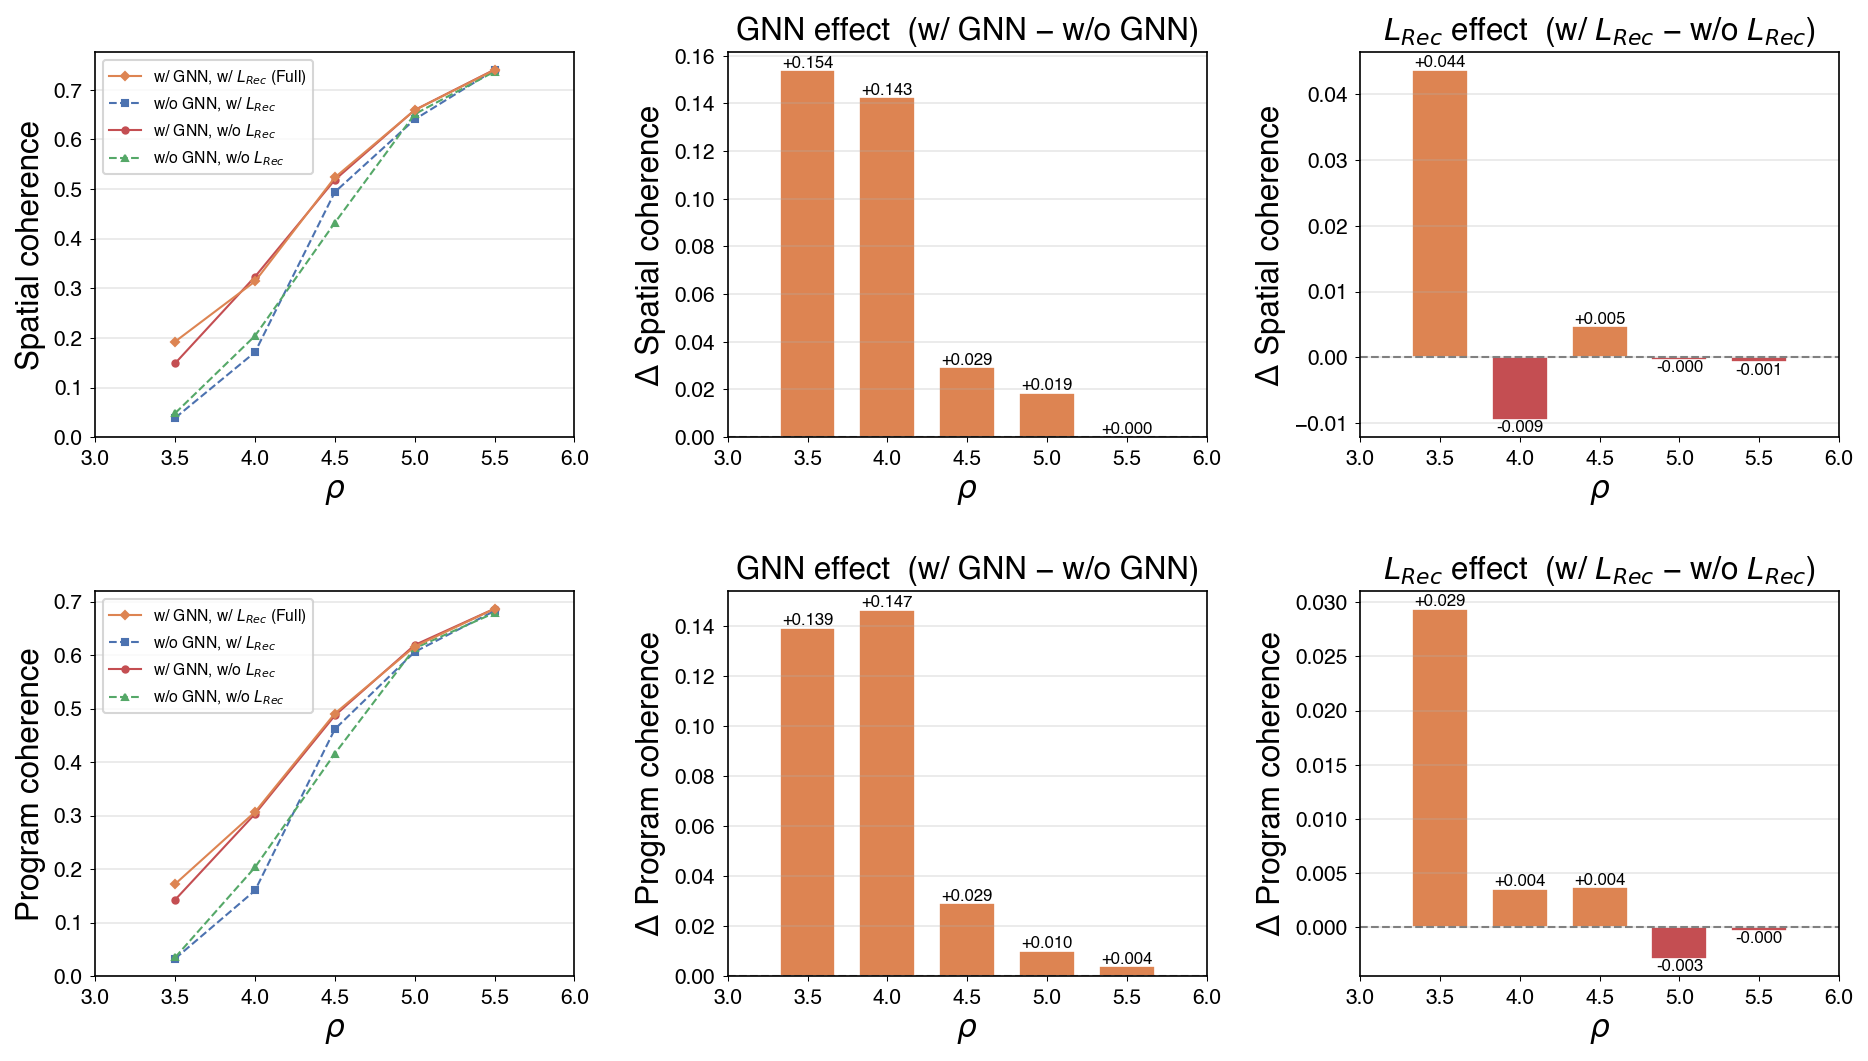

In [ ]:

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.linewidth'] = 0.8

STYLES = {
    'L4_noRAE': {'color': '#C44E52', 'marker': 'o', 'ls': '-',  'label': 'w/ GNN, w/o RAE'},
    'L0_RAE':   {'color': '#4C72B0', 'marker': 's', 'ls': '--', 'label': 'w/o GNN, w/ RAE'},
    'L0_noRAE': {'color': '#55A868', 'marker': '^', 'ls': '--', 'label': 'w/o GNN, w/o RAE'},
    'L4_RAE':   {'color': '#DD8452', 'marker': 'D', 'ls': '-',  'label': 'w/ GNN, w/ RAE (Full)'},
}

LABEL_ORDER = ['L4_noRAE', 'L0_RAE', 'L0_noRAE', 'L4_RAE']

METRICS = [
    ('moran_I_abs_mean',      'moran_I_abs_std',      "Spatial coherence",        "Spatial coherence"),
    ('loading_corr_abs_mean', 'loading_corr_abs_std', "Program coherence",    "Program coherence"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.subplots_adjust(hspace=0.40, wspace=0.32)

for row, (col_mean, col_std, metric_short, metric_long) in enumerate(METRICS):
    pivot = df_rae_summary_show.pivot(index='ref_noise_ratio', columns='label', values=col_mean)

    # ---- (a/d) All 4 conditions ----
    ax = axes[row, 0]
    for lbl in LABEL_ORDER:
        sub = df_rae_summary_show[df_rae_summary_show['label'] == lbl].sort_values('ref_noise_ratio')
        st  = STYLES[lbl]
        mean = sub[col_mean].values
        std  = sub[col_std].values
        ax.plot(sub['ref_noise_ratio'], mean,
                marker=st['marker'], color=st['color'], ls=st['ls'],
                linewidth=1.0, markersize=3, label=st['label'])
        # ax.fill_between(sub['ref_noise_ratio'], mean - std, mean + std,
        #                 color=st['color'], alpha=0.10)
    ax.set_xlabel(r'$\rho$', fontsize=15)
    ax.set_ylabel(metric_short, fontsize=15)
    #ax.set_title(f'({chr(97 + row*3)}) {metric_long}: all conditions', fontsize=15)
    #ax.legend(fontsize=8, frameon=False)

    handles, labels = ax.get_legend_handles_labels()

    handle_dict = dict(zip(labels, handles))

    desired_order = [
        'w/ GNN, w/ RAE (Full)',   
        'w/o GNN, w/ RAE',
        'w/ GNN, w/o RAE',
        'w/o GNN, w/o RAE',        
    ]
    new_labels = [
        r'w/ GNN, w/ $L_{Rec}$ (Full)',   
        r'w/o GNN, w/ $L_{Rec}$',
        r'w/ GNN, w/o $L_{Rec}$',
        r'w/o GNN, w/o $L_{Rec}$',        
    ]

    ordered_handles = [handle_dict[l] for l in desired_order]
    ax.legend(ordered_handles, desired_order, fontsize=7.5)
    # reset labels for legends [1,2,3,4] -> [a,b,c,d]
    legend = ax.get_legend()
    for text, new_label in zip(legend.get_texts(), new_labels):
        text.set_text(new_label)

    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

    # ---- (b/e) Δ GNN = L4_RAE − L0_RAE ----
    ax = axes[row, 1]
    delta = pivot['L4_RAE'] - pivot['L0_RAE']
    colors = ['#DD8452' if d > 0 else '#4C72B0' for d in delta.values]
    bars = ax.bar(delta.index, delta.values, width=0.35,
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel(r'$\rho$', fontsize=15)
    ax.set_ylabel(f'Δ {metric_short}', fontsize=15)
    ax.set_title(r'GNN effect  (w/ GNN − w/o GNN)', fontsize=15)
    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, delta.values):
        offset = 0.000 if val >= 0 else -0.000
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{val:+.3f}', ha='center',
                va='bottom' if val >= 0 else 'top', fontsize=8)

    # ---- (c/f) Δ RAE = L4_RAE − L4_noRAE ----
    ax = axes[row, 2]
    delta = pivot['L4_RAE'] - pivot['L4_noRAE']
    colors = ['#DD8452' if d > 0 else '#C44E52' for d in delta.values]
    bars = ax.bar(delta.index, delta.values, width=0.35,
                  color=colors, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel(r'$\rho$', fontsize=15)
    ax.set_ylabel(f'Δ {metric_short}', fontsize=15)
    ax.set_title(r'$L_{Rec}$ effect  (w/ $L_{Rec}$ − w/o $L_{Rec}$)', fontsize=15)
    ax.set_xticks(noise_levels)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, delta.values):
        offset = 0.000 if val >= 0 else -0.000
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{val:+.3f}', ha='center',
                va='bottom' if val >= 0 else 'top', fontsize=8)

out_prefix = os.path.join(BASE_PATH, f'ablation_graph_rae_lib{library_size}_v{v}')
# plt.savefig(f'{out_prefix}.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{out_prefix}.png', dpi=300, bbox_inches='tight')
print(f"Saved: {out_prefix}.pdf / .png")  
plt.show()